# Experiment 2
### Implement Maximum Likelihood Estimation (MLE) for a Given Dataset and Estimate Parameters of a Selected Probability Distribution

**Core Idea of MLE:**

We choose parameter values that make the observed data most probable.

Example:

If your data = heights around 170 cm, then mean = 170 is more likely than mean = 300.

So MLE tries to find:

- Best Mean (μ)
- Best Standard Deviation (σ)

for a chosen distribution.

In [10]:
# Import Required Libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import minimize

sns.set(style="whitegrid")
np.random.seed(42)

In [11]:
# Generate Sample Dataset

# Assume real-world height-like data
data = np.random.normal(loc=170, scale=8, size=500)

print("First 10 Data Values:")
print(data[:10])

First 10 Data Values:
[173.97371322 168.89388559 175.1815083  182.18423885 168.126773
 168.12690434 182.63370252 176.13947783 166.24420491 174.34048035]


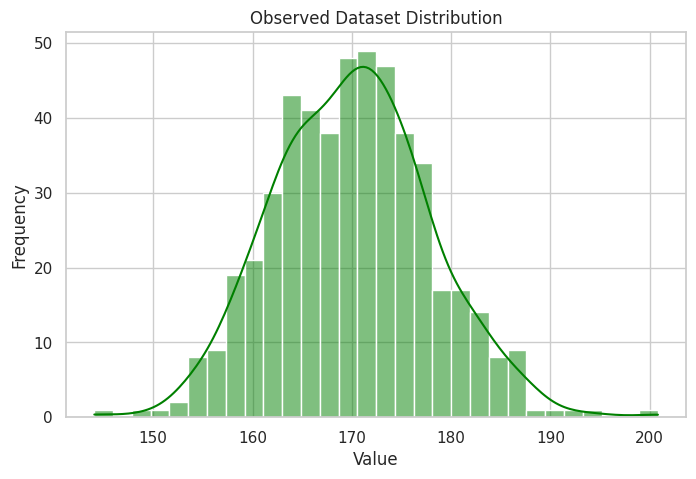

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(data, bins=30, kde=True, color='green')
plt.title("Observed Dataset Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

In [13]:
# Negative Log Likelihood Function

def negative_log_likelihood(params):

    mu = params[0]
    sigma = params[1]

    # Sigma cannot be zero or negative
    if sigma <= 0:
        return np.inf

    # Compute negative log likelihood
    nll = -np.sum(norm.logpdf(data, loc=mu, scale=sigma))

    return nll

In [14]:
initial_guess = [160, 5]
result = minimize(negative_log_likelihood, initial_guess)

mle_mu = result.x[0]
mle_sigma = result.x[1]

print("Estimated Mean (μ):", round(mle_mu,2))
print("Estimated Std Dev (σ):", round(mle_sigma,2))

Estimated Mean (μ): 170.05
Estimated Std Dev (σ): 7.84


In [15]:
print("Actual Mean Used to Generate Data = 170")
print("Actual Std Dev Used = 8")

Actual Mean Used to Generate Data = 170
Actual Std Dev Used = 8


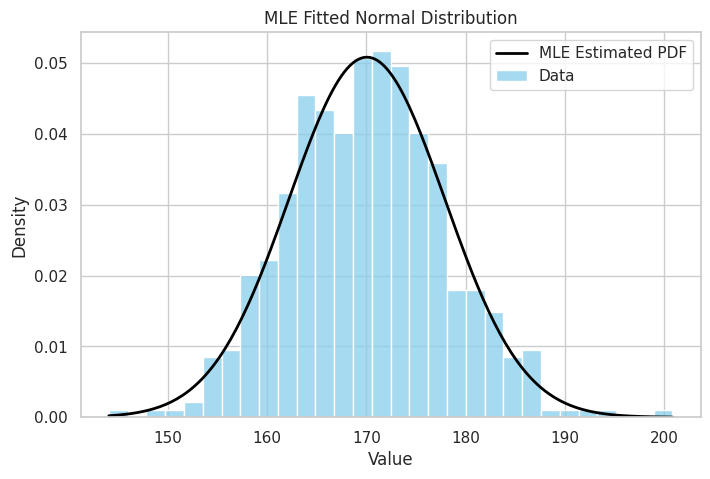

In [18]:
x = np.linspace(min(data), max(data), 200)

pdf = norm.pdf(x, loc=mle_mu, scale=mle_sigma)

plt.figure(figsize=(8,5))
sns.histplot(data, bins=30, stat='density', color='skyblue', label="Data")
plt.plot(x, pdf, color='black', linewidth=2, label='MLE Estimated PDF')

plt.title("MLE Fitted Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

In [17]:
mu_builtin, sigma_builtin = norm.fit(data)

print("SciPy Fit Mean:", round(mu_builtin,2))
print("SciPy Fit Std:", round(sigma_builtin,2))

print("Sample Mean:", round(np.mean(data),2))
print("Sample Std:", round(np.std(data),2))

SciPy Fit Mean: 170.05
SciPy Fit Std: 7.84
Sample Mean: 170.05
Sample Std: 7.84


## Result Analysis

- Estimated mean should be close to 170.
- Estimated sigma should be close to 8.
- Red fitted curve should align with histogram.
- This confirms MLE successfully recovered hidden parameters.